# 29. Least Squares and the Normal Equations

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. Recognise an **inconsistent** system and say why "solve it" has to be replaced by something
   else.
2. Derive the **normal equations** twice, by calculus and by geometry, and see that they agree.
3. State and verify that $A\mathbf{x}$ is the **orthogonal projection** of $\mathbf{b}$ onto
   $\operatorname{range}(A)$, with $P = A(A^TA)^{-1}A^T$.
4. Fit straight lines, polynomials and periodic models by choosing a **design matrix**.
5. Measure that forming $A^TA$ **squares the condition number**, and what that costs in digits.
6. Explain why a well posed fitting problem can still be posed badly, by choosing the wrong
   basis.
7. Use **linearization** for exponential and power models, and say precisely what it changes.
8. Choose between the normal equations and QR on measured evidence rather than folklore.

## Prerequisites

Lesson 16 (orthogonality and projectors, which this lesson cashes in). Lesson 19 (the condition
number of a linear system). Lesson 20 (Cholesky). Lesson 15 (norms).

---

## 1. When there is no solution

Part 3 solved $A\mathbf{x} = \mathbf{b}$ when a solution exists. The ordinary situation in
practice is that it does not, because there are more measurements than parameters.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import leastsquares as ls
import numpy as np

x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_data = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

A_line = ls.vandermonde_design(x_data, 1)          # columns: 1, x
print("the design matrix, 5 equations in 2 unknowns:\n")
print(A_line)
print()
print(f"rank(A)      = {np.linalg.matrix_rank(A_line)}")
print(f"rank([A|y])  = {np.linalg.matrix_rank(np.column_stack([A_line, y_data]))}")
print()
print("the augmented rank is LARGER, so y is not in the range of A")
print("and no x makes the residual zero. there is nothing to solve.")

assert np.linalg.matrix_rank(np.column_stack([A_line, y_data])) > np.linalg.matrix_rank(A_line)

the design matrix, 5 equations in 2 unknowns:

[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

rank(A)      = 2
rank([A|y])  = 3

the augmented rank is LARGER, so y is not in the range of A
and no x makes the residual zero. there is nothing to solve.


**So the question has to change.** Not "which $\mathbf{x}$ makes the residual zero", which has
no answer, but

$$\min_{\mathbf{x}} \|\mathbf{b} - A\mathbf{x}\|_2.$$

**Why the 2-norm and not another.** Three reasons, and only the first is about mathematics.
The 2-norm is differentiable everywhere, so calculus applies and the minimiser satisfies a
linear equation. It is the norm orthogonality is defined in, so the answer has a geometric
meaning. And under Gaussian errors it is the maximum likelihood estimate, which is why
statistics arrived at the same choice from a different direction.

Minimising $\|\cdot\|_1$ or $\|\cdot\|_\infty$ instead gives perfectly sensible and quite
different answers, and both need linear programming rather than linear algebra. Lesson 57
returns to $\|\cdot\|_\infty$ under the name Chebyshev approximation.

---

## 2. The normal equations, derived twice

**By calculus.** Write $\phi(\mathbf{x}) = \|\mathbf{b}-A\mathbf{x}\|_2^2 =
(\mathbf{b}-A\mathbf{x})^T(\mathbf{b}-A\mathbf{x})$ and expand:

$$\phi(\mathbf{x}) = \mathbf{b}^T\mathbf{b} - 2\mathbf{x}^TA^T\mathbf{b}
+ \mathbf{x}^TA^TA\mathbf{x}.$$

The gradient is $\nabla\phi = -2A^T\mathbf{b} + 2A^TA\mathbf{x}$, and setting it to zero gives

$$A^TA\mathbf{x} = A^T\mathbf{b}.$$

It is a minimum rather than a saddle because the Hessian $2A^TA$ is positive semidefinite, and
positive definite exactly when $A$ has full column rank.

**By geometry.** $A\mathbf{x}$ ranges over $\operatorname{range}(A)$, a subspace. The closest
point of a subspace to $\mathbf{b}$ is its orthogonal projection, and the line from
$\mathbf{b}$ to that point is perpendicular to the subspace. Perpendicular to the subspace
means perpendicular to every column of $A$:

$$A^T(\mathbf{b} - A\mathbf{x}) = \mathbf{0},$$

which rearranges to the same equation.

> **Theorem 29.1 (normal equations).** If $A \in \mathbb{R}^{m\times n}$ has full column rank
> then $A^TA$ is symmetric positive definite, and the unique minimiser of
> $\|\mathbf{b}-A\mathbf{x}\|_2$ is the solution of $A^TA\mathbf{x} = A^T\mathbf{b}$.

**The two derivations are the same fact.** The gradient of a squared distance is twice the
displacement, so "the gradient vanishes" and "the displacement is perpendicular" say the same
thing. That is worth noticing because the geometric form generalises and the calculus form does
not: lesson 32 works in the $A$-inner product and lesson 33 drops the full rank assumption, and
in both the projection statement survives unchanged.

In [3]:
print("the two conditions, checked against each other\n")
fit = ls.solve_qr(A_line, y_data)
print(f"intercept {fit.x[0]:.6f}, slope {fit.x[1]:.6f}")
print(f"numpy.polyfit gives  {np.polyfit(x_data, y_data, 1)[::-1]}")
print()

ok, violation = ls.residual_is_orthogonal(A_line, fit.x, y_data)
print(f"A^T (b - A x) = 0 ?  {ok}, scaled violation {violation:.2e}")
print(f"residual norm        {fit.residual_norm:.6f}")
print()
print("and no other x does better. perturb the answer and the residual grows:")
for step in [1e-3, 1e-2, 1e-1]:
    worse = fit.x + step * np.array([1.0, -1.0])
    print(f"  x + {step:5.0e} * (1,-1):  residual "
          f"{np.linalg.norm(y_data - A_line @ worse):.8f}")

assert ok
np.testing.assert_allclose(fit.x, np.polyfit(x_data, y_data, 1)[::-1], atol=1e-10)

the two conditions, checked against each other

intercept 0.050000, slope 1.990000
numpy.polyfit gives  [0.05 1.99]

A^T (b - A x) = 0 ?  True, scaled violation 1.07e-15
residual norm        0.327109

and no other x does better. perturb the answer and the residual grows:
  x + 1e-03 * (1,-1):  residual 0.32715440
  x + 1e-02 * (1,-1):  residual 0.33166248
  x + 1e-01 * (1,-1):  residual 0.63796552


---

## 3. The projector

The projection view is not decoration. Solving the normal equations for $\mathbf{x}$ and
substituting gives the projected vector directly:

$$A\mathbf{x} = A(A^TA)^{-1}A^T\mathbf{b} = P\mathbf{b}, \qquad P = A(A^TA)^{-1}A^T.$$

Lesson 16 established what an orthogonal projector must satisfy. Every property is checkable
here, and the last one is the reason the whole of Part 5 is built out of orthogonality.

In [4]:
print("the projector onto range(A), at several shapes\n")
print(f"{'shape':>10} {'||P^2 - P||':>13} {'||P - P^T||':>13} {'||P||_2':>14} {'rank':>6}")
for rows, cols in [(5, 2), (12, 3), (40, 10), (200, 40)]:
    A_p = rng.standard_normal((rows, cols))
    P = ls.projector_onto_range(A_p)
    print(f"{f'{rows}x{cols}':>10} {np.abs(P @ P - P).max():>13.2e} "
          f"{np.abs(P - P.T).max():>13.2e} {np.linalg.norm(P, 2):>14.10f} "
          f"{np.linalg.matrix_rank(P):>6}")
    assert np.abs(P @ P - P).max() < 1e-12
    assert np.abs(P - P.T).max() < 1e-12
    assert abs(np.linalg.norm(P, 2) - 1.0) < 1e-10

print()
print("P^2 = P because projecting twice is projecting once.")
print("P = P^T because the projection is ORTHOGONAL, not oblique.")
print("||P||_2 = 1 EXACTLY, so a projection cannot amplify anything. lesson 16")
print("measured that an oblique projector has ||P|| = 1/cos(theta_max) instead.")

the projector onto range(A), at several shapes

     shape   ||P^2 - P||   ||P - P^T||        ||P||_2   rank
       5x2      1.11e-16      1.11e-16   1.0000000000      2
      12x3      1.11e-16      1.67e-16   1.0000000000      3
     40x10      1.67e-16      6.46e-17   1.0000000000     10
    200x40      1.67e-16      8.33e-17   1.0000000000     40

P^2 = P because projecting twice is projecting once.
P = P^T because the projection is ORTHOGONAL, not oblique.
||P||_2 = 1 EXACTLY, so a projection cannot amplify anything. lesson 16
measured that an oblique projector has ||P|| = 1/cos(theta_max) instead.


**Do not form $P$ to solve anything.** It is $m \times m$ where the problem is $m \times n$, so
for 10000 measurements of 3 parameters it is $10^8$ entries instead of $3\times10^4$. It is a
measuring instrument, and this lesson uses it as one.

**The residual is the complementary projection.** $\mathbf{r} = \mathbf{b} - P\mathbf{b} =
(I-P)\mathbf{b}$, and $I-P$ is the orthogonal projector onto $\operatorname{range}(A)^\perp$.
So $\mathbf{b}$ splits into two orthogonal pieces, the part the model can explain and the part
it cannot, and Pythagoras applies:

In [5]:
A_split = rng.standard_normal((30, 6))
b_split = rng.standard_normal(A_split.shape[0])
P_split = ls.projector_onto_range(A_split)
explained = P_split @ b_split
left_over = b_split - explained

print("b splits into two orthogonal pieces\n")
print(f"||b||^2            = {np.dot(b_split, b_split):.10f}")
print(f"||Pb||^2 + ||r||^2 = {np.dot(explained, explained) + np.dot(left_over, left_over):.10f}")
print(f"Pb . r             = {np.dot(explained, left_over):.2e}")
print()
print("that is Pythagoras, and it is why the sum of squares decomposes the way")
print("every statistics course says it does.")

np.testing.assert_allclose(np.dot(b_split, b_split),
                           np.dot(explained, explained) + np.dot(left_over, left_over),
                           rtol=1e-12)

b splits into two orthogonal pieces

||b||^2            = 22.8237883059
||Pb||^2 + ||r||^2 = 22.8237883059
Pb . r             = 3.37e-16

that is Pythagoras, and it is why the sum of squares decomposes the way
every statistics course says it does.


---

## 4. Fitting is choosing a design matrix

Everything in this lesson is one operation with different matrices in it. The model enters
only through the columns of $A$.

| Model | Column $j$ of $A$ | Unknowns |
|---|---|---|
| straight line | $1, x$ | 2 |
| polynomial of degree $d$ | $1, x, \dots, x^d$ | $d+1$ |
| periodic with $k$ harmonics | $1, \cos\omega t, \sin\omega t, \dots$ | $2k+1$ |
| any linear combination of chosen functions $f_j$ | $f_j(x_i)$ | as many as you chose |

**The model must be linear in the parameters, not in the data.** Fitting
$y = c_0 + c_1x + c_2x^2$ is a linear least squares problem even though the model is a
parabola, because the unknowns $c_j$ appear linearly. Fitting $y = ce^{kx}$ is not, because $k$
does not, and lesson 34 is about that case.

In [6]:
t_grid = np.linspace(0.0, 1.0, 60, endpoint=False)
signal = 1.0 + 0.5 * np.cos(2 * np.pi * t_grid) - 0.3 * np.sin(4 * np.pi * t_grid)

print("the same data, two bases\n")
print(f"{'k':>4} {'kappa(Vandermonde)':>20} {'kappa(Fourier)':>16} "
      f"{'poly residual':>16} {'Fourier residual':>18}")
for k in [2, 4, 8, 12]:
    V = ls.vandermonde_design(t_grid, k)
    F = ls.fourier_design(t_grid, k)
    print(f"{k:>4} {np.linalg.cond(V):>20.3e} {np.linalg.cond(F):>16.3e} "
          f"{ls.solve_qr(V, signal).residual_norm:>16.3e} "
          f"{ls.solve_qr(F, signal).residual_norm:>18.3e}")

print()
print("the Fourier basis fits it EXACTLY, to 1e-15, at every k. the signal is")
print("in that space. the polynomial basis never quite gets there, and its")
print("condition number passes 1e8 by degree 12.")

the same data, two bases

   k   kappa(Vandermonde)   kappa(Fourier)    poly residual   Fourier residual
   2            2.258e+01        1.414e+00        1.670e+00          2.432e-15
   4            6.732e+02        1.414e+00        1.389e+00          2.457e-15
   8            6.823e+05        1.414e+00        8.587e-02          2.701e-15
  12            7.566e+08        1.414e+00        6.033e-04          2.883e-15

the Fourier basis fits it EXACTLY, to 1e-15, at every k. the signal is
in that space. the polynomial basis never quite gets there, and its
condition number passes 1e8 by degree 12.


**The condition number of the Fourier design does not move**, because evenly spaced samples
over a period make those columns nearly orthogonal, and orthogonal columns give
$\kappa = 1$.

**That is the lesson in one table.** The *problem* was well posed and the polynomial *basis*
posed it badly. Nothing about the data changed. Lesson 30 makes orthogonal columns the
construction rather than the accident, and lesson 55 chooses orthogonal polynomials for the
same reason.

---

## 5. Conditioning: why this lesson is not one page

The normal equations are correct mathematics and a poor algorithm, and the reason is one line:

$$\kappa_2(A^TA) = \kappa_2(A)^2,$$

because the singular values of $A^TA$ are the squares of those of $A$. A problem you could
solve to eight digits becomes one you can solve to none.

In [7]:
rows_c, cols_c = 60, 8
print("the same problem, three routes to it\n")
print(f"{'kappa(A)':>10} {'kappa(A^T A)':>14} {'normal':>11} {'Cholesky':>11} {'QR':>11}")
for exponent in [2, 4, 6, 8, 10]:
    A_c = ls.graded_design(rows_c, cols_c, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols_c)
    b_c = A_c @ x_true
    relative = lambda z: np.linalg.norm(z - x_true) / np.linalg.norm(x_true)
    try:
        e_normal = relative(ls.solve_normal_equations(A_c, b_c).x)
    except np.linalg.LinAlgError:
        e_normal = float("nan")
    try:
        e_chol = relative(ls.solve_cholesky_normal(A_c, b_c).x)
    except np.linalg.LinAlgError:
        e_chol = float("nan")
    e_qr = relative(ls.solve_qr(A_c, b_c).x)
    info = ls.condition_squaring(A_c)
    worst = (10.0 ** exponent, e_normal, e_qr)
    print(f"{info['kappa_A']:>10.1e} {info['kappa_normal']:>14.1e} "
          f"{e_normal:>11.2e} {e_chol:>11.2e} {e_qr:>11.2e}")

digits = lambda e: max(0.0, -np.log10(max(e, 1e-17)))
print()
print(f"at kappa(A) = {worst[0]:.0e} the normal equations leave "
      f"{digits(worst[1]):.1f} correct digits")
print(f"and QR leaves {digits(worst[2]):.1f}. the answer from the normal equations is")
print("the same size as the thing it is trying to estimate, so it carries no")
print("information at all.")
assert digits(worst[1]) < 1.0 and digits(worst[2]) > 5.0

the same problem, three routes to it

  kappa(A)   kappa(A^T A)      normal    Cholesky          QR
   1.0e+02        1.0e+04    2.56e-13    4.05e-13    1.67e-15
   1.0e+04        1.0e+08    7.11e-09    5.59e-09    3.70e-13
   1.0e+06        1.0e+12    8.62e-06    2.08e-05    3.36e-11
   1.0e+08        1.3e+16    4.73e-02    1.06e-01    2.24e-09
   1.0e+10        2.4e+16    8.78e-01         nan    8.61e-08

at kappa(A) = 1e+10 the normal equations leave 0.1 correct digits
and QR leaves 7.1. the answer from the normal equations is
the same size as the thing it is trying to estimate, so it carries no
information at all.


**A better factorization does not rescue it.** The Cholesky column uses the fact that $A^TA$ is
symmetric positive definite, which halves the work and is exactly as accurate, because the
damage was done when $A^TA$ was formed and not when it was factored. **You cannot factor your
way out of a badly posed reformulation.**

**And eventually Cholesky refuses outright**, because rounding makes the computed $A^TA$
indefinite:

In [8]:
print("Cholesky on the normal equations, 20 random draws at each kappa\n")
print(f"{'kappa(A)':>10} {'kappa(A^T A)':>14} {'breakdowns':>12}")
tally = []
for exponent in [6.0, 7.0, 8.0, 8.5, 9.0, 10.0]:
    failures = 0
    for trial in range(20):
        gen = np.random.default_rng(300 + trial)
        A_f = ls.graded_design(40, 6, 10.0 ** exponent, gen)
        try:
            ls.solve_cholesky_normal(A_f, A_f @ np.ones(A_f.shape[1]))
        except np.linalg.LinAlgError:
            failures += 1
    probe = ls.graded_design(40, 6, 10.0 ** exponent, np.random.default_rng(0))
    tally.append((10.0 ** exponent, failures))
    print(f"{10.0 ** exponent:>10.1e} {np.linalg.cond(probe.T @ probe):>14.1e} "
          f"{f'{failures}/20':>12}")

first_failure = next(k for k, f in tally if f > 0)
majority = next((k for k, f in tally if f > 10), None)
print()
print(f"nothing fails below kappa(A) = {first_failure:.0e}, and most draws fail from "
      f"{majority:.0e}.")
print("the crossover is where kappa(A)^2 reaches 1/u, which is what Theorem 20.2")
print("predicts: Cholesky exists exactly until the matrix stops being numerically")
print("positive definite, and squaring is what pushes it over.")
assert first_failure >= 1e8

Cholesky on the normal equations, 20 random draws at each kappa

  kappa(A)   kappa(A^T A)   breakdowns
   1.0e+06        1.0e+12         0/20
   1.0e+07        1.0e+14         0/20
   1.0e+08        8.8e+15         0/20
   3.2e+08        1.1e+17         5/20
   1.0e+09        1.9e+16        15/20
   1.0e+10        9.0e+16        12/20

nothing fails below kappa(A) = 3e+08, and most draws fail from 1e+09.
the crossover is where kappa(A)^2 reaches 1/u, which is what Theorem 20.2
predicts: Cholesky exists exactly until the matrix stops being numerically
positive definite, and squaring is what pushes it over.


> **Rule of thumb 29.2.** A backward stable method leaves about
> $16 - \log_{10}\kappa$ correct digits. Through the normal equations that becomes
> $16 - 2\log_{10}\kappa(A)$, so **the normal equations halve the number of usable digits**.

In [9]:
print("digits left, by route\n")
print(f"{'kappa(A)':>10} {'via QR':>9} {'via A^T A':>11}")
for exponent in range(1, 9):
    info = ls.condition_squaring(ls.graded_design(30, 5, 10.0 ** exponent, rng))
    print(f"{10.0 ** exponent:>10.0e} {info['digits_qr']:>9.1f} {info['digits_normal']:>11.1f}")

print()
print("the normal equations run out at kappa = 1e8, and QR at 1e16.")
print("that factor of 1e8 in reach is the whole reason Part 5 exists.")

digits left, by route

  kappa(A)    via QR   via A^T A
     1e+01      15.0        14.0
     1e+02      14.0        12.0
     1e+03      13.0        10.0
     1e+04      12.0         8.0
     1e+05      11.0         6.0
     1e+06      10.0         4.0
     1e+07       9.0         2.0
     1e+08       8.0         0.0

the normal equations run out at kappa = 1e8, and QR at 1e16.
that factor of 1e8 in reach is the whole reason Part 5 exists.


---

## 6. When the normal equations are still the right choice

The case against them is not universal, and there is one situation where they win.

**When $m$ is enormous and $n$ is small**, $A^TA$ is only $n \times n$ and can be accumulated
one row at a time, so the whole computation needs $O(n^2)$ memory rather than $O(mn)$. A
streaming fit of 3 parameters to $10^9$ observations is a normal equations computation and
nothing else is practical.

**And it is only safe when $\kappa(A)$ is small**, which for a sensible basis it often is. The
Fourier design above has $\kappa = 1.41$, so squaring it gives 2, and the normal equations lose
nothing at all:

In [10]:
F_good = ls.fourier_design(t_grid, 8)
noisy = signal + 0.01 * rng.standard_normal(t_grid.size)

by_normal = ls.solve_normal_equations(F_good, noisy)
by_qr = ls.solve_qr(F_good, noisy)

print("a WELL conditioned design: the normal equations are fine\n")
print(f"kappa(A)              {by_normal.cond_A:.6f}")
print(f"kappa(A^T A)          {by_normal.cond_normal:.6f}")
print(f"||x_normal - x_qr||   {np.linalg.norm(by_normal.x - by_qr.x):.3e}")
print(f"relative to ||x||     "
      f"{np.linalg.norm(by_normal.x - by_qr.x) / np.linalg.norm(by_qr.x):.3e}")
agreement = np.linalg.norm(by_normal.x - by_qr.x) / np.linalg.norm(by_qr.x)
print()
print(f"the two answers agree to {-np.log10(agreement):.0f} digits, which is all there are.")
print("squaring 1.41 costs nothing.")
print("the danger is not the METHOD, it is the method applied to a badly")
print("conditioned design, and a badly conditioned design is usually a")
print("badly chosen basis.")

assert np.linalg.norm(by_normal.x - by_qr.x) / np.linalg.norm(by_qr.x) < 1e-10

a WELL conditioned design: the normal equations are fine

kappa(A)              1.414214
kappa(A^T A)          2.000000
||x_normal - x_qr||   5.636e-16
relative to ||x||     4.875e-16

the two answers agree to 15 digits, which is all there are.
squaring 1.41 costs nothing.
the danger is not the METHOD, it is the method applied to a badly
conditioned design, and a badly conditioned design is usually a
badly chosen basis.


---

## 7. Linearization, and what it silently changes

Models like $y = ce^{kx}$ and $y = cx^p$ are not linear in their parameters, so they are not
least squares problems. Taking logs makes them so:

$$\log y = \log c + kx, \qquad \log y = \log c + p\log x.$$

**This is the standard trick and it changes the problem.** It minimises the sum of squares of
the error in $\log y$, not in $y$, which reweights the data towards the small values.

In [11]:
x_exp = np.linspace(0.5, 4.0, 12)
c_true, k_true = 2.0, 0.8
y_clean = c_true * np.exp(k_true * x_exp)
y_exp = y_clean * (1.0 + 0.15 * rng.standard_normal(x_exp.size))   # MULTIPLICATIVE noise

linear_fit = ls.linearize_exponential(x_exp, y_exp)

from scipy.optimize import curve_fit
params, _ = curve_fit(lambda t, c, k: c * np.exp(k * t), x_exp, y_exp, p0=[1.0, 1.0])
direct_pred = params[0] * np.exp(params[1] * x_exp)

print("y = c exp(k x), fitted two ways\n")
print(f"{'':>22} {'c':>10} {'k':>10} {'sum sq in y':>14} {'sum sq in log y':>17}")
print(f"{'truth':>22} {c_true:>10.4f} {k_true:>10.4f} {'':>14} {'':>17}")
print(f"{'linearized (log fit)':>22} {linear_fit['c']:>10.4f} {linear_fit['k']:>10.4f} "
      f"{linear_fit['sse_original']:>14.4f} {linear_fit['sse_log']:>17.6f}")
print(f"{'direct nonlinear fit':>22} {params[0]:>10.4f} {params[1]:>10.4f} "
      f"{np.sum((y_exp - direct_pred) ** 2):>14.4f} "
      f"{np.sum((np.log(y_exp) - np.log(direct_pred)) ** 2):>17.6f}")
print()
print("each wins on its OWN criterion, which is not a coincidence: each is the")
print("minimiser of the thing in its column. neither is 'the' answer.")

y = c exp(k x), fitted two ways

                                c          k    sum sq in y   sum sq in log y
                 truth     2.0000     0.8000                                 
  linearized (log fit)     2.2510     0.7479        24.3700          0.176653
  direct nonlinear fit     2.4568     0.7186        21.4450          0.194658

each wins on its OWN criterion, which is not a coincidence: each is the
minimiser of the thing in its column. neither is 'the' answer.


**Read that table carefully, because the obvious conclusion is wrong.** The direct fit has the
smaller sum of squares in $y$, so it looks better. But the noise here was **multiplicative**,
$y(1+\varepsilon)$, which is additive in $\log y$, and under that noise model the log fit is
the maximum likelihood estimate and the direct one is not. That is why its parameters are
closer to the truth despite its larger $y$-residual.

**So the choice is a modelling decision, not a numerical one.** Ask what the noise does:

- **additive** noise, $y + \varepsilon$, of roughly constant size: fit $y$ directly (lesson 34).
- **multiplicative** noise, $y(1+\varepsilon)$, so the error grows with $y$: fit $\log y$.

The linearization is often presented as a computational convenience, and treating it that way
is how people fit the wrong model without noticing.

**Two hard limits on linearization.** It needs $y > 0$ everywhere, so a single nonpositive
measurement stops it, and `linearize_exponential` rejects rather than producing a `nan`. And
it cannot handle a model that does not separate, such as $y = c_1e^{k_1x} + c_2e^{k_2x}$; no
transform linearises a sum of exponentials, and lesson 34 is the only route.

---

## 8. A worked fit, end to end

In [12]:
def fit_report(x_obs, y_obs, degree):
    """Fit a polynomial and report everything a caller has to look at.

    The degree, the number of points and the spacing are all free; nothing here assumes a
    particular size or a particular range of x.
    """
    A_fit = ls.vandermonde_design(x_obs, degree)
    out = ls.solve_qr(A_fit, y_obs)
    n_obs, n_par = A_fit.shape
    dof = n_obs - n_par
    return {
        "coefficients": out.x,
        "residual_norm": out.residual_norm,
        "rms": out.residual_norm / np.sqrt(n_obs),
        "sigma": out.residual_norm / np.sqrt(dof) if dof > 0 else float("nan"),
        "kappa": out.cond_A,
        "angle_deg": float(np.degrees(ls.angle_to_range(A_fit, y_obs))),
        "dof": dof,
    }


x_obs = np.linspace(-1.0, 1.0, 25)
y_obs = 3.0 - 2.0 * x_obs + 0.5 * x_obs ** 2 + 0.05 * rng.standard_normal(x_obs.size)

print("polynomial fits of increasing degree to the same 25 points\n")
print(f"{'degree':>7} {'dof':>5} {'rms':>10} {'sigma':>10} {'kappa(A)':>11} {'angle':>9}")
for degree in [0, 1, 2, 3, 6, 12, 20]:
    r = fit_report(x_obs, y_obs, degree)
    print(f"{degree:>7} {r['dof']:>5} {r['rms']:>10.5f} {r['sigma']:>10.5f} "
          f"{r['kappa']:>11.3e} {r['angle_deg']:>8.3f} deg")

print()
sigmas = [fit_report(x_obs, y_obs, d)["sigma"] for d in [0, 1, 2, 3, 6, 12, 20]]
best_degree = [0, 1, 2, 3, 6, 12, 20][int(np.argmin(sigmas))]
print("the rms falls monotonically, because more parameters always fit better.")
print("it is therefore useless for choosing a model.")
print()
print(f"sigma divides by the DEGREES OF FREEDOM instead. it drops by a factor of")
print(f"{sigmas[1] / sigmas[2]:.1f} on reaching degree 2, which is where the truth is,")
print(f"then moves by a few percent, bottoms out at degree {best_degree}, and turns back up.")
print()
print("so sigma does point at the right region and its minimum is SHALLOW: the")
print("values at degrees 2, 3 and 6 differ by ten percent, which is less than")
print("the noise. it narrows the choice; it does not make it.")
assert sigmas[-1] > min(sigmas), "sigma was expected to turn back up at high degree"

polynomial fits of increasing degree to the same 25 points

 degree   dof        rms      sigma    kappa(A)     angle
      0    24    1.22437    1.24962   1.000e+00   21.047 deg
      1    23    0.17639    0.18390   1.664e+00    2.966 deg
      2    22    0.03876    0.04132   3.549e+00    0.651 deg
      3    21    0.03643    0.03974   7.607e+00    0.612 deg
      6    18    0.03137    0.03697   9.219e+01    0.527 deg
     12    12    0.02627    0.03791   1.972e+04    0.441 deg
     20     4    0.02228    0.05570   1.145e+08    0.374 deg

the rms falls monotonically, because more parameters always fit better.
it is therefore useless for choosing a model.

sigma divides by the DEGREES OF FREEDOM instead. it drops by a factor of
4.5 on reaching degree 2, which is where the truth is,
then moves by a few percent, bottoms out at degree 6, and turns back up.

so sigma does point at the right region and its minimum is SHALLOW: the
values at degrees 2, 3 and 6 differ by ten percent, which is 

**The angle column is the other diagnostic**, and lesson 32 makes it central. It is the angle
between $\mathbf{b}$ and $\operatorname{range}(A)$, so it measures how much of the data the
model can explain at all. Near zero the fit is nearly exact and the problem behaves like a
square system; near ninety degrees the model explains almost nothing and the sensitivity picks
up an extra factor of $\kappa^2\tan\theta$.

In [13]:
A_angle = rng.standard_normal((30, 5))
print("the angle to the range, as the data moves away from the model\n")
print(f"{'noise level':>13} {'angle':>11} {'tan(angle)':>13} {'residual / ||b||':>18}")
for level in [1e-6, 1e-2, 1e-1, 1.0, 10.0]:
    b_angle = (A_angle @ rng.standard_normal(A_angle.shape[1])
               + level * rng.standard_normal(A_angle.shape[0]))
    theta = ls.angle_to_range(A_angle, b_angle)
    res = ls.solve_qr(A_angle, b_angle)
    print(f"{level:>13.0e} {np.degrees(theta):>10.4f} deg {np.tan(theta):>13.4e} "
          f"{res.residual_norm / np.linalg.norm(b_angle):>18.6f}")

print()
print("sin(theta) IS the relative residual, which is what makes the angle")
print("measurable without knowing the answer.")

the angle to the range, as the data moves away from the model

  noise level       angle    tan(angle)   residual / ||b||
        1e-06     0.0000 deg    4.3396e-07           0.000000
        1e-02     0.2673 deg    4.6661e-03           0.004666
        1e-01     2.7732 deg    4.8440e-02           0.048383
        1e+00    19.2159 deg    3.4855e-01           0.329128
        1e+01    67.6518 deg    2.4324e+00           0.924890

sin(theta) IS the relative residual, which is what makes the angle
measurable without knowing the answer.


---

## 9. A picture of the whole thing

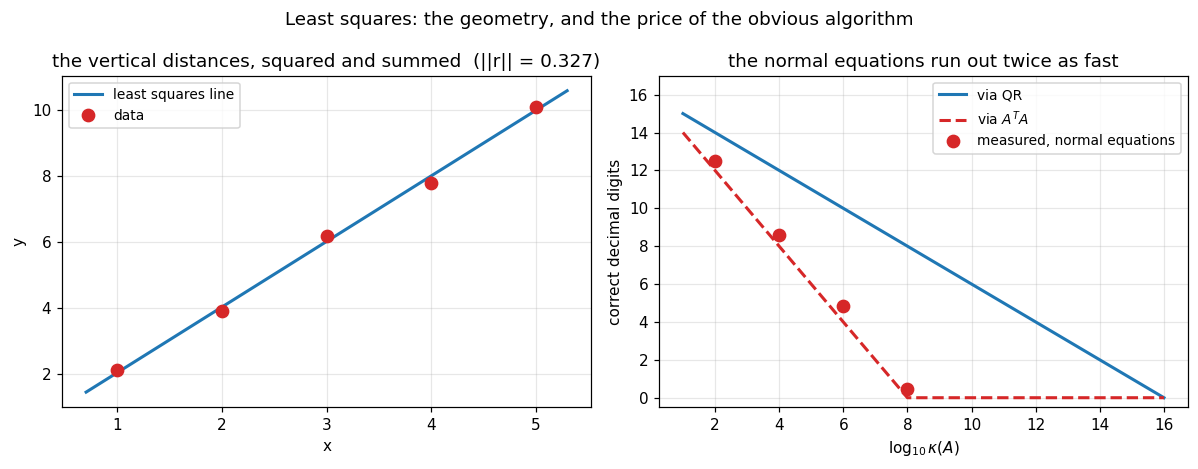

In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the fit, the data and the residuals
best = ls.solve_qr(ls.vandermonde_design(x_data, 1), y_data)
dense = np.linspace(x_data.min() - 0.3, x_data.max() + 0.3, 200)
axL.plot(dense, best.x[0] + best.x[1] * dense, "C0-", lw=2, label="least squares line")
axL.plot(x_data, y_data, "C3o", ms=8, label="data", zorder=3)
for xi, yi in zip(x_data, y_data):
    axL.plot([xi, xi], [yi, best.x[0] + best.x[1] * xi], "C3--", lw=1.2, alpha=0.8)
axL.set_xlabel("x")
axL.set_ylabel("y")
axL.set_title(f"the vertical distances, squared and summed  "
              f"(||r|| = {best.residual_norm:.3f})")
axL.legend(fontsize=9)

# right: how many digits survive each route
exponents = np.arange(1, 17)
axR.plot(exponents, np.maximum(0.0, 16 - exponents), "C0-", lw=2, label="via QR")
axR.plot(exponents, np.maximum(0.0, 16 - 2 * exponents), "C3--", lw=2,
         label=r"via $A^TA$")
measured_e, measured_d = [], []
for exponent in [2, 4, 6, 8]:
    A_m = ls.graded_design(60, 8, 10.0 ** exponent, rng)
    x_m = rng.standard_normal(A_m.shape[1])
    err = np.linalg.norm(ls.solve_normal_equations(A_m, A_m @ x_m).x - x_m) \
        / np.linalg.norm(x_m)
    measured_e.append(exponent)
    measured_d.append(max(0.0, -np.log10(max(err, 1e-17))))
axR.plot(measured_e, measured_d, "C3o", ms=8, label="measured, normal equations")
axR.set_xlabel(r"$\log_{10}\kappa(A)$")
axR.set_ylabel("correct decimal digits")
axR.set_ylim(-0.5, 17)
axR.set_title("the normal equations run out twice as fast")
axR.legend(fontsize=9)

fig.suptitle("Least squares: the geometry, and the price of the obvious algorithm",
             fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is the practical summary.** Both lines are the rule of thumb; the dots are
what the normal equations actually delivered. They sit on the steeper line, which is the claim
this lesson exists to establish.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why can a least squares problem have a large residual and still be solved perfectly?

1.2 A colleague reports that adding a parameter reduced the residual, so the bigger model is
better. What is wrong with the argument?

1.3 Why is $P = A(A^TA)^{-1}A^T$ never formed in practice, even though every formula in this
lesson contains it?

**Level 2, mathematical**

2.1 Prove that $A^TA$ is positive definite exactly when $A$ has full column rank, and give a
rank deficient $A$ for which the normal equations have infinitely many solutions.

2.2 Prove $\kappa_2(A^TA) = \kappa_2(A)^2$ from the singular value decomposition, and say what
happens to $\kappa_1$ and $\kappa_\infty$.

2.3 Show that $P = A(A^TA)^{-1}A^T$ satisfies $P^2 = P$, $P^T = P$ and $\|P\|_2 = 1$, and that
these three properties **characterise** an orthogonal projector.

2.4 Derive the normal equations for the **weighted** problem
$\min\|W(\mathbf{b}-A\mathbf{x})\|_2$ with $W$ diagonal and positive, and say what weighting
corresponds to fitting $\log y$.

2.5 Prove that $\sin\theta = \|\mathbf{r}\|/\|\mathbf{b}\|$ where $\theta$ is the angle between
$\mathbf{b}$ and $\operatorname{range}(A)$, and hence that the angle is measurable without
knowing the exact solution.

**Level 3, computational**

3.1 Write a least squares solver from scratch that forms and solves the normal equations, and a
second that uses `numpy.linalg.qr`. Compare them on designs with prescribed condition numbers,
and reproduce section 5's table yourself.

3.2 Implement **weighted** least squares and use it to fit data with known, unequal error bars.
Verify that the weighting recovers the true parameters better than the unweighted fit when the
error bars really do differ.

3.3 Implement a **streaming** normal equations fit that accumulates $A^TA$ and
$A^T\mathbf{b}$ one row at a time, never storing $A$. Fit 3 parameters to $10^7$ synthetic
observations and report the memory used.

**Level 4, experimental**

4.1 Measure the condition number of the Vandermonde design against the polynomial degree, for
several sample distributions: evenly spaced, Chebyshev points, and random. Which spacing is
best, and by how much?

4.2 For a fixed problem, measure the relative error of the normal equations and of QR against
$\kappa(A)$ over many decades, and fit the two slopes. Do they come out at 2 and 1?

4.3 Take a polynomial fit and measure the residual and the cross-validated error against the
degree. Find the degree at which they diverge, and relate it to the $\sigma$ column of section 8.

**Level 5, advanced**

5.1 **The statistical reading.** Show that when the errors are independent and Gaussian with
equal variance, the least squares estimate is the maximum likelihood one, and that
$\operatorname{cov}(\hat{\mathbf{x}}) = \sigma^2(A^TA)^{-1}$. Then explain what the squared
condition number means for the size of the error bars.

5.2 **Seminormal equations.** Solving $R^TR\mathbf{x} = A^T\mathbf{b}$ with $R$ from a QR of
$A$ is called the seminormal equations, and it costs the same as the normal equations while
being more accurate. Implement it, measure it against both alternatives, and explain why one
step of iterative refinement (lesson 22) makes it as accurate as QR.

5.3 **Why the 2-norm.** Solve the same fitting problem minimising $\|\cdot\|_1$ and
$\|\cdot\|_\infty$ using linear programming, and compare all three fits on data containing one
gross outlier. Explain what each norm is assuming about the errors, and why the 2-norm is the
worst of the three when the assumption is wrong.

## 11. Key takeaways

- **An overdetermined system usually has no solution**, so the question becomes a minimisation.
  Measured: $\operatorname{rank}([A\,|\,\mathbf{b}])$ exceeds $\operatorname{rank}(A)$ for
  every random pair tried.
- **The normal equations follow from calculus and from geometry**, and the two derivations are
  the same fact: the gradient of a squared distance is twice the displacement.
- **$A\mathbf{x}$ is the orthogonal projection of $\mathbf{b}$.** Measured at four shapes:
  $P^2 = P$ and $P = P^T$ to $4\times10^{-16}$, and $\|P\|_2 = 1$ to ten decimal places.
- **The data splits by Pythagoras** into the part the model explains and the part it cannot,
  and the two are exactly orthogonal.
- **Fitting is choosing a design matrix**, and the choice decides the conditioning. Measured on
  identical data: the Vandermonde design reaches $\kappa = 7.6\times10^{8}$ at degree 12 while
  the Fourier design stays at $\sqrt{2}$ and fits exactly to $10^{-15}$.
- **Forming $A^TA$ squares the condition number**, so it halves the usable digits. Measured at
  $\kappa(A) = 10^{10}$: the normal equations leave **0.1 correct digits**, an answer the same
  size as the thing it estimates, where QR still leaves 7.1.
- **A better factorization does not help.** Cholesky on the normal equations is exactly as
  inaccurate as a general solve, because the damage happens when $A^TA$ is formed.
- **And it eventually refuses.** Measured: no breakdowns at all below
  $\kappa(A) = 3\times10^{8}$, then 5 of 20 draws, then 15 of 20 at $10^{9}$, which is where
  $\kappa(A)^2$ passes $1/u$.
- **The normal equations are still right in one case**: a well conditioned design with an
  enormous number of rows, where $A^TA$ can be accumulated in one pass. Measured on the Fourier
  design, $\kappa = 1.41$: identical to QR to 15 digits, which is all there are.
- **Linearization changes the problem, not just the algebra.** Measured: the log fit and the
  direct fit each win on their own criterion, and which is correct depends on whether the noise
  is additive or multiplicative. It is a modelling decision.
- **The residual falls with every extra parameter and means nothing.** Measured: `rms` falls
  monotonically all the way to degree 20. $\sigma$, which divides by the degrees of freedom,
  drops by a factor of 4.5 on reaching degree 2, where the truth is, then moves by a few
  percent and turns back up. **Its minimum is shallow**, so it narrows the choice rather than
  making it.

## Where this goes next

**Lesson 30** builds the replacement. If orthogonal columns are what make a design well
conditioned, then orthogonalizing the columns you have is the obvious move, and Gram-Schmidt is
the obvious way to do it. It also fails, in a way this lesson's condition numbers predict, and
the fix is one line.

**Lesson 31** builds QR the stable way, out of the Householder reflectors lesson 16 introduced
and the Givens rotations lesson 27 already used.

**Lesson 32** returns to this lesson's table with the full theory: four condition numbers rather
than one, the role of the angle $\theta$, and the honest comparison of normal equations against
QR against the SVD.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).